##  Table of Contents
* 1. [Libraries](#1)
* 2. [Dataset](#2)
* 3. [Feature Engineering](#3)
      * 3.1 [3.1 Perform column saperation](#3.1)
      * 3.2 [Transforming date and time variables to datetime](#3.2)
      * 3.3 [Creating 3 more variables: transaction_day, transaction_month, transaction_year](#3.3)
      * 3.4 [Creating 3 more variables: transaction_hour, transaction_minute, transaction_second](#3.4)
      * 3.5 [Total Revenue per Transaction](#3.5)
* 4. [Exploratory Data Analysis](#4)
      * 4.1 [Descriptive Statistics](#4.1)
      * 4.2 [Transactions by Day and Month](#4.2)
      * 4.3 [Transactions by Hour](#4.3)
      * 4.4 [Items Sold per Month](#4.4)
      * 4.5 [Transactions and Items sold per Store Location](#4.5)
      * 4.6 [Total Revenue by Store Location](#4.6)
      * 4.7 [Top Product Categories: Transactions vs Quantity Sold](#4.7)
      * 4.8 [Top Product Types: Transactions vs Quantity Sold](#4.8)
        * 4.8.1 [Comparison of product_type transactions vs quantity sold](#4.8.1)
      * 4.9 [Product Category Quantity Sold per Store Location](#4.9)
      * 4.10 [Product Revenue Analysis](#4.10)
        * 4.10.1 [Most Expensive Products on Average](#4.10.1)
        * 4.10.2 [Revenue by product category](#4.10.2)
        * 4.10.3 [Revenue by product type](#4.10.3)
        * 4.10.4 [Revenue by product category in each store location](#4.10.4)
        * 4.10.5 [Top 10 Products by: Revenue, Quantity Sold and Transactions](#4.10.5)
        * 4.10.6 [Hourly Revenue in each Store Location](#4.10.6)
        * 4.10.7 [Trend of Total Revenue Over Time](#4.10.7)
      * 4.11 [Relationship Between Unit Price, Transaction Quantity, and Total Revenue](#4.11)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
import seaborn as sns
from datetime import date
from datetime import datetime

## 2. Dataset <a id=2><a/>

In [2]:
df = pd.read_csv('coffee-shop-sales-revenue.csv')

In [3]:
df.head(5)

,transaction_id|transaction_date|transaction_time|transaction_qty|store_id|store_location|product_id|unit_price|product_category|product_type|product_detail
0,1|2023-01-01|07:06:11|2|5|Lower Manhattan|32|3...
1,2|2023-01-01|07:08:56|2|5|Lower Manhattan|57|3...
2,3|2023-01-01|07:14:04|2|5|Lower Manhattan|59|4...
3,4|2023-01-01|07:20:24|1|5|Lower Manhattan|22|2...
4,5|2023-01-01|07:22:41|2|5|Lower Manhattan|57|3...


## 3. Feature Engineering <a id=3><a/>

## 3.1 Perform column saperation <a id=3.1></a>

In [4]:
type(df.iloc[1,0])

str

In [5]:
transaction_id = []
transaction_date = []
transaction_time =[] 
transaction_qty =[]
store_id =[]
store_location =[]
product_id =[]
unit_price =[]
product_category =[]
product_type =[]
product_detail =[]

for i in range(0,df.shape[0]):
    l = df.iloc[i,0].split("|")
    transaction_id.append(l[0])
    transaction_date.append(l[1])
    transaction_time.append(l[2])
    transaction_qty.append(l[3])
    store_id.append(l[4])
    store_location.append(l[5])
    product_id.append(l[6])
    unit_price.append(l[7])
    product_category.append(l[8])
    product_type.append(l[9])
    product_detail.append(l[10])

In [6]:
dic = {
    "transaction_id" :transaction_id,
    "transaction_date" :transaction_date,
    "transaction_time" :transaction_time,
    "transaction_qty" :transaction_qty,
    "store_id" :store_id,
    "store_location" :store_location,
    "product_id" :product_id,
    "unit_price" :unit_price,
    "product_category" :product_category,
    "product_type" :product_type,
    "product_detail" :product_detail
}

In [7]:
df = pd.DataFrame(dic)

In [8]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


## 3.2 Transforming date and time variables to datetime <a id=3.2></a>

In [9]:
df['transaction_time']= pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df['transaction_date']=pd.to_datetime(df['transaction_date'])
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,1900-01-01 20:18:41,2,8,Hell's Kitchen,44,2.5,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2023-06-30,1900-01-01 20:25:10,2,8,Hell's Kitchen,49,3.0,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2023-06-30,1900-01-01 20:31:34,1,8,Hell's Kitchen,45,3.0,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2023-06-30,1900-01-01 20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


## 3.3 Creating 3 more variables: transaction_day, transaction_month, transaction_year <a id=3.3></a>

In [10]:


df['transaction_day'] = df['transaction_date'].dt.day_name()
df['transaction_month'] = df['transaction_date'].dt.month
df['transaction_year'] = df['transaction_date'].dt.year

## 3.4 Creating 3 more variables: transaction_hour, transaction_minute, transaction_second <a id=3.4></a>

In [11]:

df['transaction_hour'] = df['transaction_time'].dt.hour
df['transaction_minute'] = df['transaction_time'].dt.minute
df['transaction_second'] = df['transaction_time'].dt.second

## 3.5 Total Revenue per Transaction <a id=3.5></a>

In [12]:
df['transaction_qty']=df['transaction_qty'].apply(float)
df['unit_price']=df['unit_price'].apply(float)

df['Total_revenue'] = df['transaction_qty'] * df['unit_price']
df.head(3)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_day,transaction_month,transaction_year,transaction_hour,transaction_minute,transaction_second,Total_revenue
0,1,2023-01-01,1900-01-01 07:06:11,2.0,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,Sunday,1,2023,7,6,11,6.0
1,2,2023-01-01,1900-01-01 07:08:56,2.0,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,Sunday,1,2023,7,8,56,6.2
2,3,2023-01-01,1900-01-01 07:14:04,2.0,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,Sunday,1,2023,7,14,4,9.0


## EDA <a id=4><a/>

## 4.1 Descriptive Statistics <a id=4.1></a>

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   transaction_id      149116 non-null  str           
 1   transaction_date    149116 non-null  datetime64[us]
 2   transaction_time    149116 non-null  datetime64[us]
 3   transaction_qty     149116 non-null  float64       
 4   store_id            149116 non-null  str           
 5   store_location      149116 non-null  str           
 6   product_id          149116 non-null  str           
 7   unit_price          149116 non-null  float64       
 8   product_category    149116 non-null  str           
 9   product_type        149116 non-null  str           
 10  product_detail      149116 non-null  str           
 11  transaction_day     149116 non-null  str           
 12  transaction_month   149116 non-null  int32         
 13  transaction_year    149116 non-null  int

In [14]:
df.isnull().sum()

transaction_id        0
transaction_date      0
transaction_time      0
transaction_qty       0
store_id              0
store_location        0
product_id            0
unit_price            0
product_category      0
product_type          0
product_detail        0
transaction_day       0
transaction_month     0
transaction_year      0
transaction_hour      0
transaction_minute    0
transaction_second    0
Total_revenue         0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,transaction_date,transaction_time,transaction_qty,unit_price,transaction_month,transaction_year,transaction_hour,transaction_minute,transaction_second,Total_revenue
count,149116,149116,149116.000000,149116.000000,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,2023-04-15 11:50:32.173609,1900-01-01 12:14:15.815795,1.438276,3.382219,3.988881,2023.0,11.735790,29.623863,29.541484,4.686367
min,2023-01-01 00:00:00,1900-01-01 06:00:00,1.000000,0.800000,1.000000,2023.0,6.000000,0.000000,0.000000,0.800000
25%,2023-03-06 00:00:00,1900-01-01 09:05:10.500000,1.000000,2.500000,3.000000,2023.0,9.000000,15.000000,15.000000,3.000000
50%,2023-04-24 00:00:00,1900-01-01 11:15:28,1.000000,3.000000,4.000000,2023.0,11.000000,30.000000,29.000000,3.750000
75%,2023-05-30 00:00:00,1900-01-01 15:25:57,2.000000,3.750000,5.000000,2023.0,15.000000,45.000000,45.000000,6.000000
max,2023-06-30 00:00:00,1900-01-01 20:59:32,8.000000,45.000000,6.000000,2023.0,20.000000,59.000000,59.000000,360.000000
std,NaN,NaN,0.542509,2.658723,1.673091,0.0,3.764662,17.291357,17.297958,4.227099


## 4.2 Transactions by Day and Month <a id=4.2></a>

In [17]:
df.groupby('transaction_month')['transaction_day'].value_counts()

transaction_month  transaction_day
1                  Monday             2814
                   Tuesday            2766
                   Sunday             2725
                   Friday             2291
                   Thursday           2283
                   Wednesday          2229
                   Saturday           2206
2                  Sunday             2433
                   Monday             2373
                   Friday             2358
                   Wednesday          2350
                   Thursday           2325
                   Saturday           2321
                   Tuesday            2199
3                  Thursday           3486
                   Friday             3486
                   Wednesday          3375
                   Monday             2816
                   Sunday             2738
                   Saturday           2732
                   Tuesday            2596
4                  Sunday             4279
                   

[]

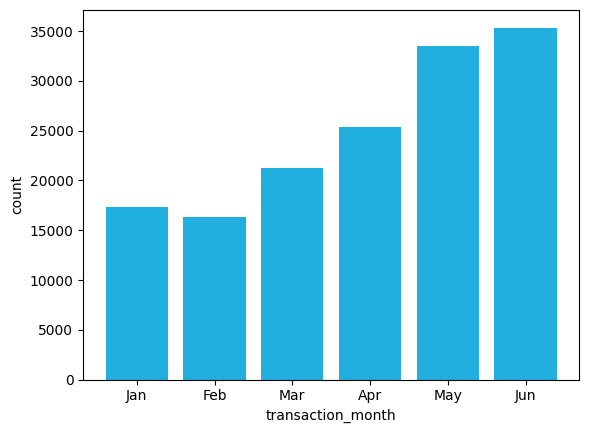

In [18]:
ax = sns.countplot(data=df,x='transaction_month',color="deepskyblue")

ax.set_xticks(range(6))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun'])

ax.plot()

##### Most transactions occur in June (35352).

## 4.3 Transactions by Hour <a id=4.3></a>

<Axes: xlabel='transaction_hour', ylabel='count'>

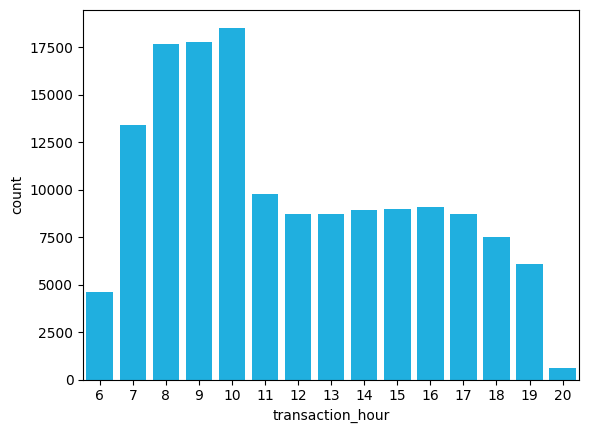

In [19]:
sns.countplot(data=df,x="transaction_hour",color="deepskyblue")

#### <span style="color:deepskyblue"> Most transactions happen in the morning hours (between 7:00-10:00).</span>

## 4.4 Items Sold per Month <a id=4.4></a>


In [20]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_day,transaction_month,transaction_year,transaction_hour,transaction_minute,transaction_second,Total_revenue
0,1,2023-01-01,1900-01-01 07:06:11,2.0,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,Sunday,1,2023,7,6,11,6.0
1,2,2023-01-01,1900-01-01 07:08:56,2.0,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,Sunday,1,2023,7,8,56,6.2
2,3,2023-01-01,1900-01-01 07:14:04,2.0,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,Sunday,1,2023,7,14,4,9.0
3,4,2023-01-01,1900-01-01 07:20:24,1.0,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,Sunday,1,2023,7,20,24,2.0
4,5,2023-01-01,1900-01-01 07:22:41,2.0,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,Sunday,1,2023,7,22,41,6.2


In [21]:
monthly_item_sales =df.groupby("transaction_month")['transaction_qty'].sum().sort_index()

Text(0.5, 1.0, 'Items sold per Month')

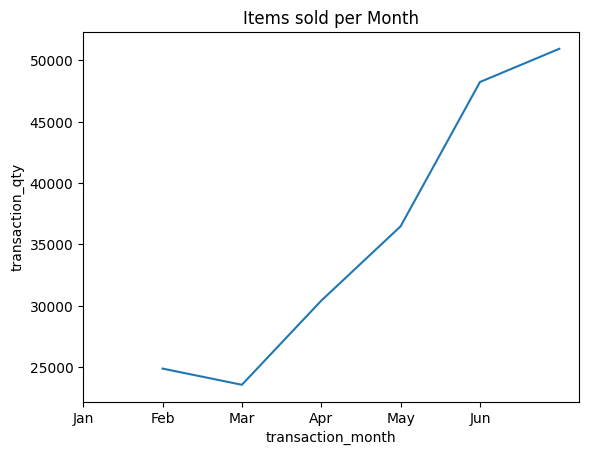

In [22]:
ax=sns.lineplot(x=monthly_item_sales.index,y=monthly_item_sales)
ax.set_xticks(range(6))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun'])
plt.title("Items sold per Month")

#### <span style="color:deepskyblue">Jun is giving heighest sales</span>

## 4.5 Transactions and Items sold per Store Location <a id=4.5></a>


In [23]:
items_per_loc=df.groupby('store_location')['transaction_qty'].sum()
transactions_per_loc=df['store_location'].value_counts()

Text(0.5, 1.0, 'Transactions Each store location')

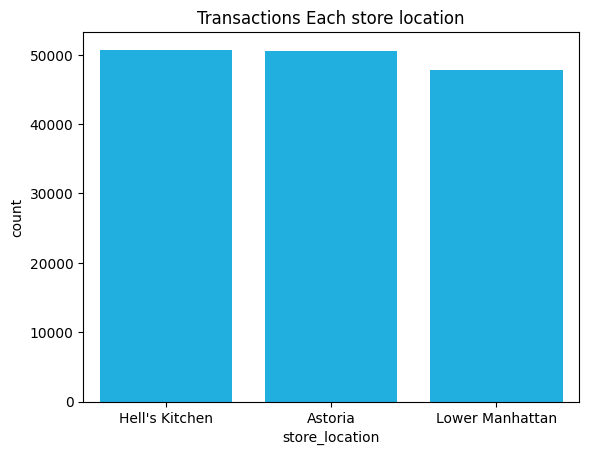

In [24]:
ax=sns.barplot(x=transactions_per_loc.index,y=transactions_per_loc,color="deepskyblue")
plt.title("Transactions Each store location")

Text(0.5, 1.0, 'Items sold Each store location')

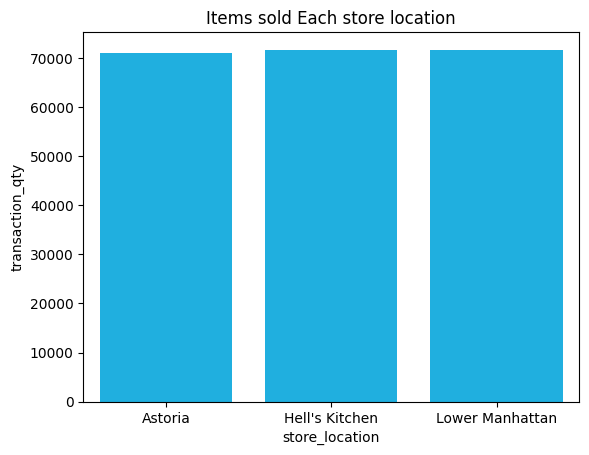

In [25]:
ax=sns.barplot(x=items_per_loc.index,y=items_per_loc,color="deepskyblue")
plt.title("Items sold Each store location")

## 4.6 Total Revenue by Store Location <a id=4.6></a>


Text(0.5, 1.0, 'Total revenue by store location')

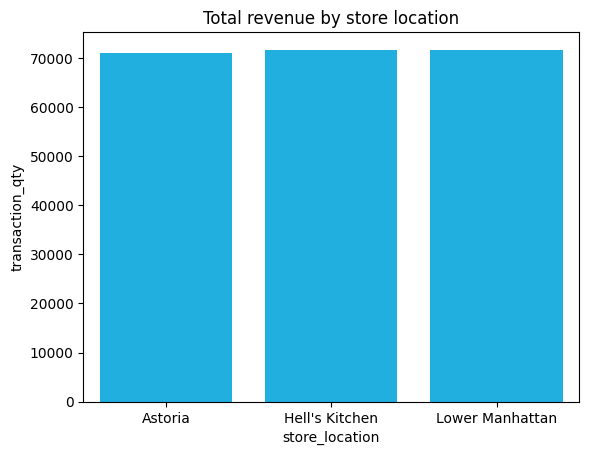

In [26]:
total_revenu_per_loc=df.groupby("store_location")['Total_revenue'].sum()

ax=sns.barplot(x=items_per_loc.index,y=items_per_loc,color="deepskyblue")
plt.title("Total revenue by store location")

## 4.7 Top Product Categories: Transactions vs Quantity Sold <a id=4.7></a>


In [27]:
quantity_per_category=df.groupby("product_category")['transaction_qty'].sum().sort_values(ascending=False)
transaction_per_category = df['product_category'].value_counts()

C:\Users\user\AppData\Local\Temp\ipykernel_8388\3631304020.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


Text(0.5, 1.0, 'Quantity sold per category')

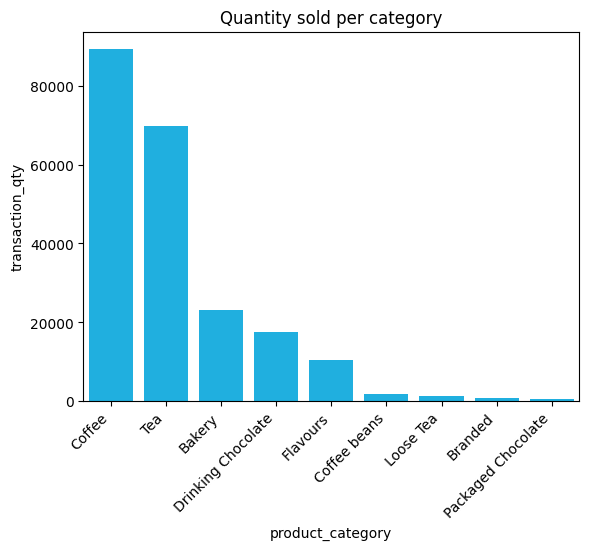

In [28]:
ax=sns.barplot(x=quantity_per_category.index,y=quantity_per_category,color="deepskyblue")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title("Quantity sold per category")

C:\Users\user\AppData\Local\Temp\ipykernel_8388\244581985.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


Text(0.5, 1.0, 'Transactions per category')

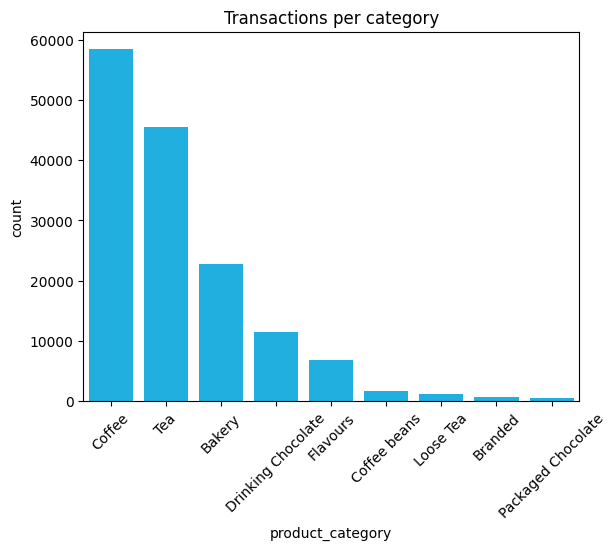

In [29]:
ax=sns.barplot(x=transaction_per_category.index,y=transaction_per_category,color="deepskyblue")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.title("Transactions per category")

## 4.8 Top Product Types: Transactions vs Quantity Sold <a id=4.8></a>


In [30]:
quantity_per_type=df.groupby("product_type")['transaction_qty'].sum().sort_values(ascending=False)[:9]
transaction_per_type = df['product_type'].value_counts()[:9]

C:\Users\user\AppData\Local\Temp\ipykernel_8388\1626197415.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


Text(0.5, 1.0, 'Quantity sold per Product Type')

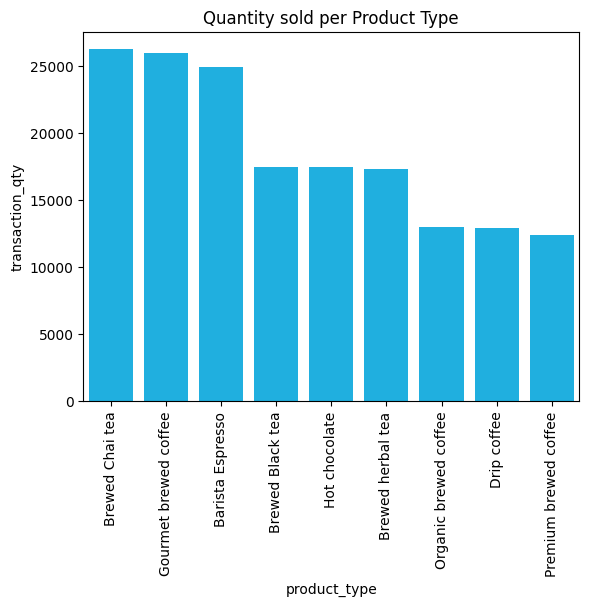

In [31]:
ax=sns.barplot(x=quantity_per_type.index,y=quantity_per_type,color="deepskyblue")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title("Quantity sold per Product Type")

C:\Users\user\AppData\Local\Temp\ipykernel_8388\3429286237.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


Text(0.5, 1.0, 'Transactions per Product Type')

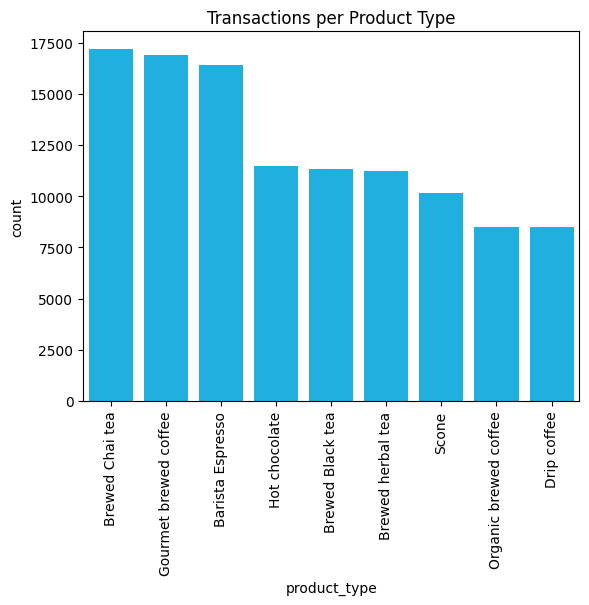

In [32]:
ax=sns.barplot(x=transaction_per_type.index,y=transaction_per_type,color="deepskyblue")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title("Transactions per Product Type")

#### <span style="color:deepskyblue">Brewed chai tea is top according to transaction quantity and quantities sold</span>

## 4.8.1 Comparison of product_type transactions vs quantity sold <a id=4.8.1></a>


## 4.9 Product Category Quantity Sold per Store Location <a id=4.9></a>


In [33]:
categorywise_locwise_quantSold=df.groupby(['store_location','product_category'])['transaction_qty'].sum().reset_index().sort_values(['store_location', 'transaction_qty'], ascending=[True, False])

<Axes: xlabel='store_location', ylabel='transaction_qty'>

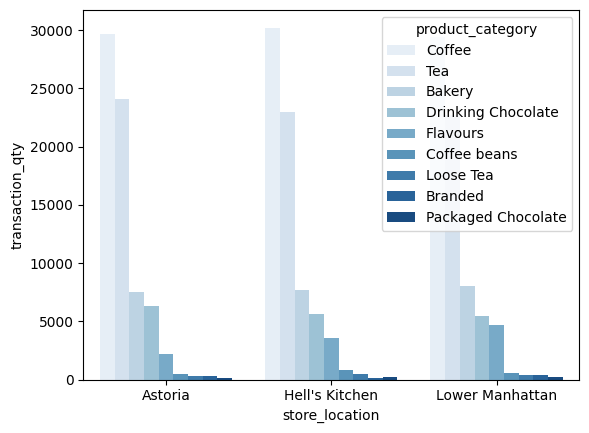

In [34]:
sns.barplot(x='store_location', y='transaction_qty', data=categorywise_locwise_quantSold, hue='product_category', palette='Blues')

##### <span style="color:deepskyblue">We see that in all three stores coffee, tea and bakery goods are the most prevalent.</span>

## 4.10 Product Revenue Analysis <a id=4.10></a>


## 4.10.1 Most Expensive Products on Average <a id=4.10.1></a>


In [35]:
product_price=df.groupby("product_type")['unit_price'].mean().sort_values(ascending=False)

C:\Users\user\AppData\Local\Temp\ipykernel_8388\354984627.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Premium Beans'),
 Text(1, 0, 'Clothing'),
 Text(2, 0, 'Organic Beans'),
 Text(3, 0, 'Gourmet Beans'),
 Text(4, 0, 'House blend Beans'),
 Text(5, 0, 'Espresso Beans'),
 Text(6, 0, 'Housewares'),
 Text(7, 0, 'Drinking Chocolate'),
 Text(8, 0, 'Green beans'),
 Text(9, 0, 'Chai tea'),
 Text(10, 0, 'Green tea'),
 Text(11, 0, 'Black tea'),
 Text(12, 0, 'Herbal tea'),
 Text(13, 0, 'Organic Chocolate'),
 Text(14, 0, 'Hot chocolate'),
 Text(15, 0, 'Pastry'),
 Text(16, 0, 'Barista Espresso'),
 Text(17, 0, 'Scone'),
 Text(18, 0, 'Biscotti'),
 Text(19, 0, 'Premium brewed coffee'),
 Text(20, 0, 'Brewed Chai tea'),
 Text(21, 0, 'Organic brewed coffee'),
 Text(22, 0, 'Brewed herbal tea'),
 Text(23, 0, 'Brewed Black tea'),
 Text(24, 0, 'Brewed Green tea'),
 Text(25, 0, 'Gourmet brewed coffee'),
 Text(26, 0, 'Drip coffee'),
 Text(27, 0, 'Sugar free syrup'),
 Text(28, 0, 'Regular syrup')]

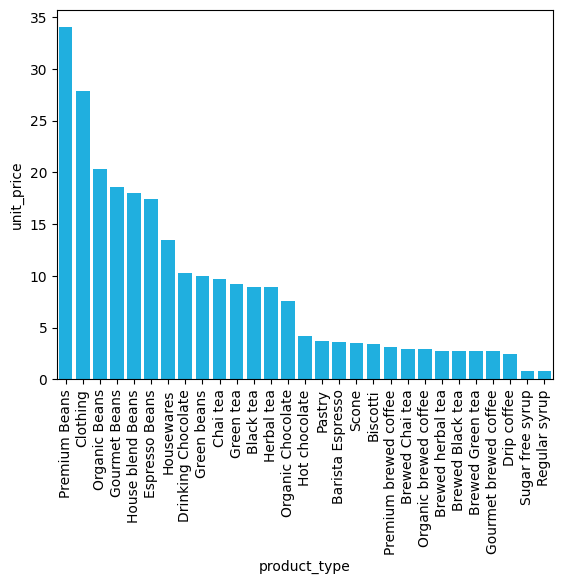

In [36]:
ax=sns.barplot(x=product_price.index,y=product_price,color="deepskyblue")
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

## 4.10.2 Revenue by product category <a id=4.10.2></a>


In [37]:
revenue_by_category=df.groupby('product_category')['Total_revenue'].sum().sort_values(ascending=False)

C:\Users\user\AppData\Local\Temp\ipykernel_8388\4156998228.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Coffee'),
 Text(1, 0, 'Tea'),
 Text(2, 0, 'Bakery'),
 Text(3, 0, 'Drinking Chocolate'),
 Text(4, 0, 'Coffee beans'),
 Text(5, 0, 'Branded'),
 Text(6, 0, 'Loose Tea'),
 Text(7, 0, 'Flavours'),
 Text(8, 0, 'Packaged Chocolate')]

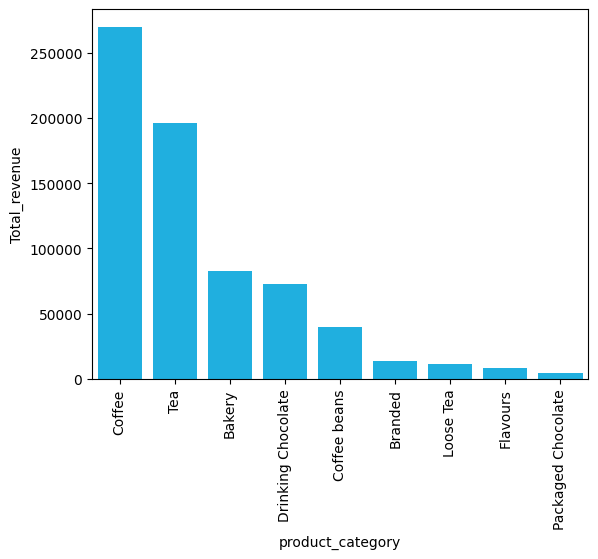

In [38]:
ax=sns.barplot(x=revenue_by_category.index,y=revenue_by_category,color="deepskyblue")
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

## 4.10.3 Revenue by product type <a id=4.10.3></a>


In [39]:
revenue_by_type=df.groupby('product_type')['Total_revenue'].sum().sort_values(ascending=False)

C:\Users\user\AppData\Local\Temp\ipykernel_8388\715470418.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


[Text(0, 0, 'Barista Espresso'),
 Text(1, 0, 'Brewed Chai tea'),
 Text(2, 0, 'Hot chocolate'),
 Text(3, 0, 'Gourmet brewed coffee'),
 Text(4, 0, 'Brewed Black tea'),
 Text(5, 0, 'Brewed herbal tea'),
 Text(6, 0, 'Premium brewed coffee'),
 Text(7, 0, 'Organic brewed coffee'),
 Text(8, 0, 'Scone'),
 Text(9, 0, 'Drip coffee'),
 Text(10, 0, 'Pastry'),
 Text(11, 0, 'Brewed Green tea'),
 Text(12, 0, 'Biscotti'),
 Text(13, 0, 'Premium Beans'),
 Text(14, 0, 'Organic Beans'),
 Text(15, 0, 'Housewares'),
 Text(16, 0, 'Gourmet Beans'),
 Text(17, 0, 'Clothing'),
 Text(18, 0, 'Regular syrup'),
 Text(19, 0, 'Espresso Beans'),
 Text(20, 0, 'Chai tea'),
 Text(21, 0, 'House blend Beans'),
 Text(22, 0, 'Herbal tea'),
 Text(23, 0, 'Drinking Chocolate'),
 Text(24, 0, 'Black tea'),
 Text(25, 0, 'Sugar free syrup'),
 Text(26, 0, 'Organic Chocolate'),
 Text(27, 0, 'Green tea'),
 Text(28, 0, 'Green beans')]

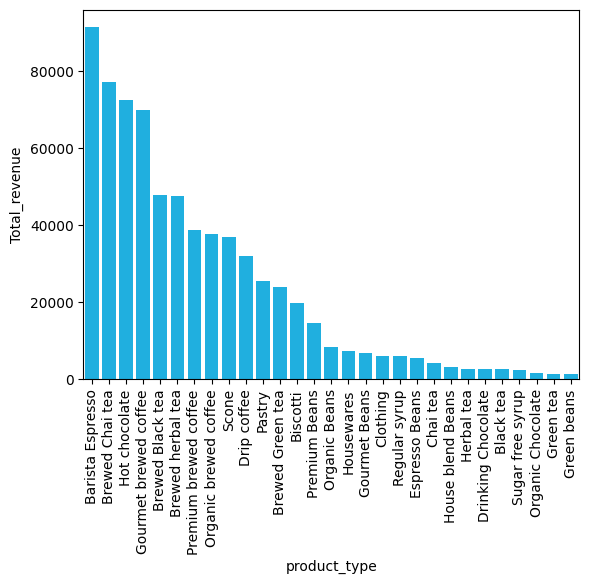

In [40]:
ax=sns.barplot(x=revenue_by_type.index,y=revenue_by_type,color="deepskyblue")
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)

## 4.10.4 Revenue by product category in each store location <a id=4.10.4></a>


In [41]:
rev=df.groupby(["store_location","product_category"])['Total_revenue'].sum().reset_index().sort_values(['store_location','Total_revenue'],ascending=[True,False])

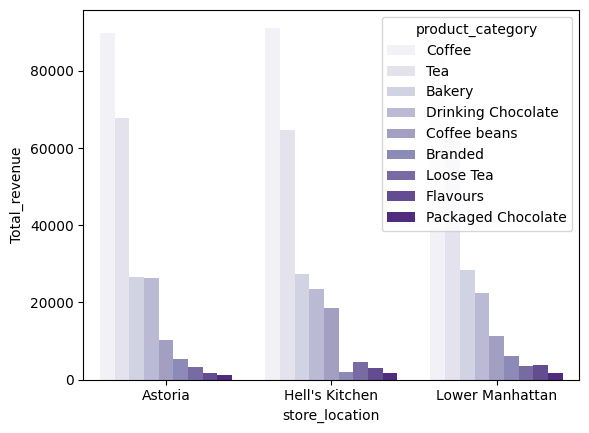

In [42]:
ax= sns.barplot(data=rev,x="store_location",y="Total_revenue",hue="product_category",palette='Purples')

## 4.10.5 Top 10 Products by: Revenue, Quantity Sold and Transactions <a id=4.10.5></a>


## 4.10.6 Hourly Revenue in each Store Location <a id=4.10.6></a>


In [43]:
hourly_revenue=df.groupby(["transaction_hour","store_location"])['Total_revenue'].sum().reset_index().sort_values(['store_location','Total_revenue'],ascending=[True,False])


<Axes: xlabel='transaction_hour', ylabel='Total_revenue'>

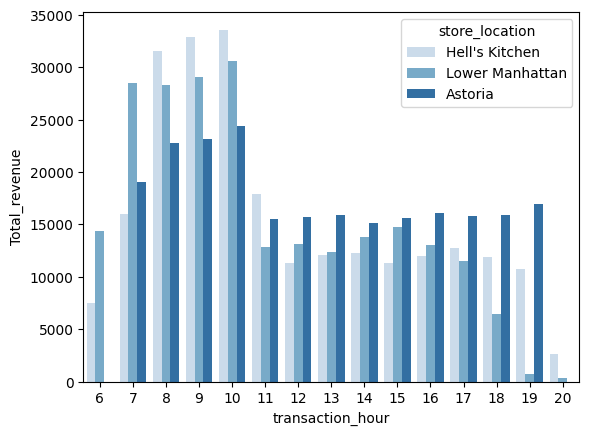

In [44]:
sns.barplot(x='transaction_hour', y='Total_revenue', hue='store_location', data=hourly_revenue, palette='Blues')

## 4.10.7 Trend of Total Revenue Over Time <a id=4.10.7></a>


<Axes: xlabel='transaction_date', ylabel='Total_revenue'>

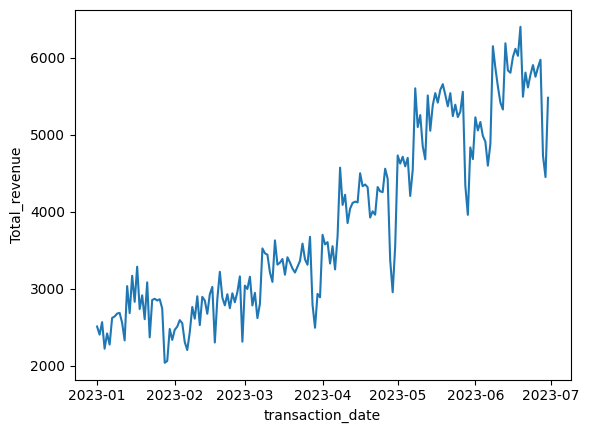

In [45]:
revenu_trend=df.groupby('transaction_date')['Total_revenue'].sum().reset_index()

sns.lineplot(data=revenu_trend,x="transaction_date",y="Total_revenue")

## 4.11 Relationship Between Unit Price, Transaction Quantity, and Total Revenue <a id=4.11></a>

In [46]:
corr = df[['transaction_qty', 'unit_price', 'Total_revenue']].corr(method='spearman')
print(corr)

                 transaction_qty  unit_price  Total_revenue
transaction_qty         1.000000   -0.160442       0.680296
unit_price             -0.160442    1.000000       0.529418
Total_revenue           0.680296    0.529418       1.000000


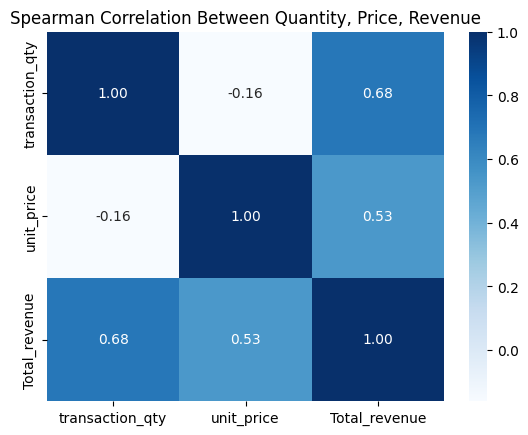

In [47]:
sns.heatmap(corr,cmap='Blues', fmt=".2f",annot=True)
plt.title("Spearman Correlation Between Quantity, Price, Revenue")
plt.show()